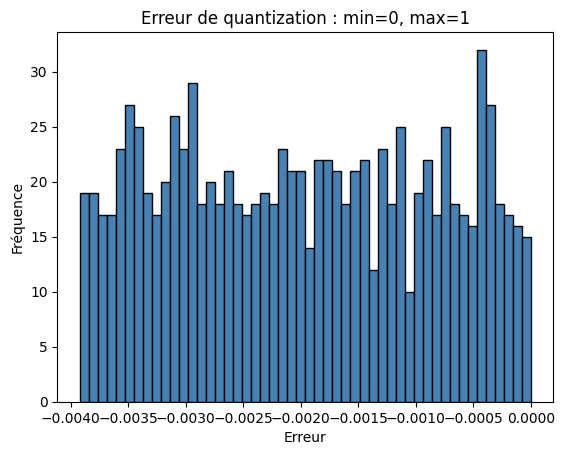

Situation 1: (np.float64(-0.0019870857959210556), np.float64(0.0011282934867809077))


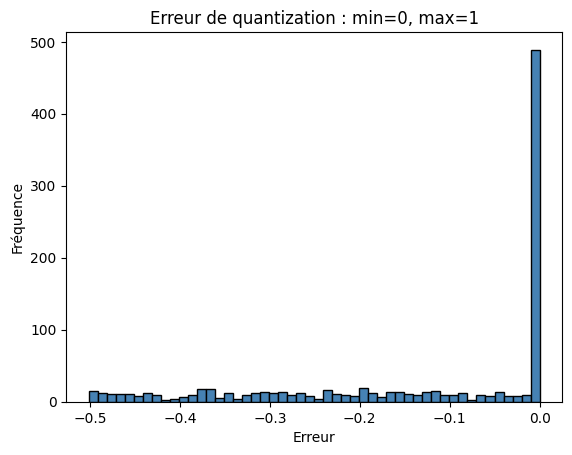

Situation 1 bis: (np.float64(-0.132393753282896), np.float64(0.16223367620324244))


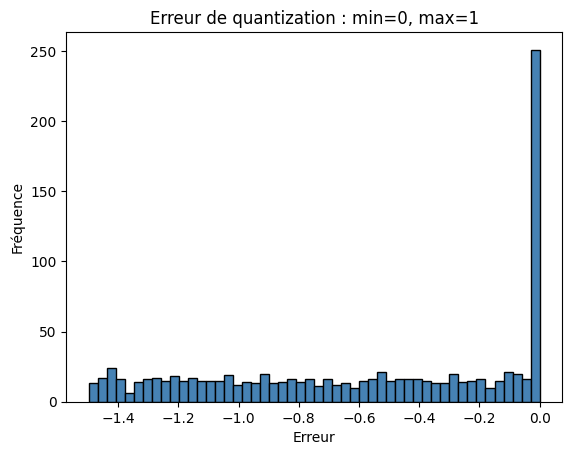

Situation 2: (np.float64(-0.570336916225521), np.float64(0.49735655901378395))


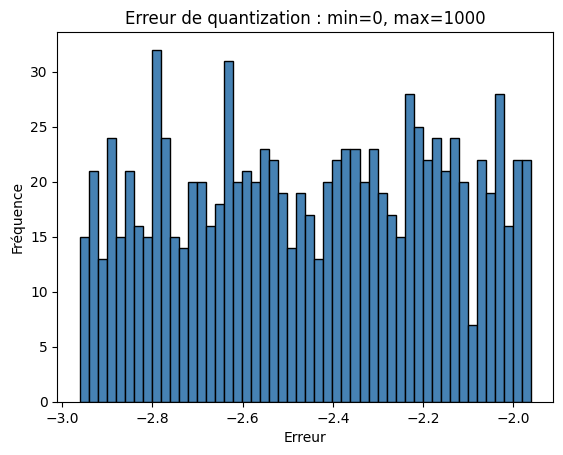

Situation 3: (np.float64(-2.451159959896841), np.float64(0.2863460638507346))


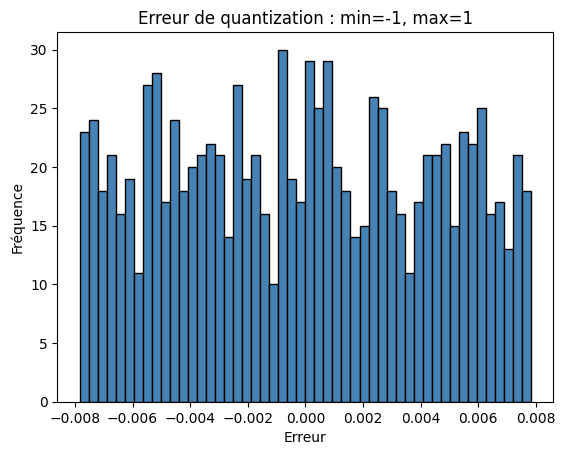

Situation 4: (np.float64(-0.00013656692848418157), np.float64(0.004478261401285926))


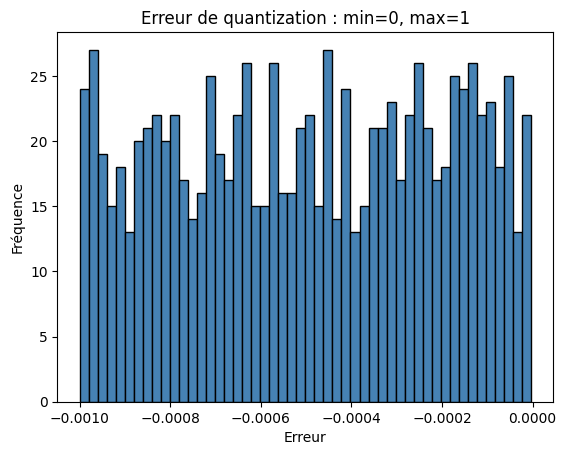

Situation 5: (np.float64(-0.0004933955602681508), np.float64(0.00029108996823710607))


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def quantize(float_value, min_range, max_range, zero=0, bits=8):
    S = (max_range - min_range) / (2**bits - 1)
    q = np.asarray(float_value) / S
    q = np.clip(q, -128, 127).astype(np.int8)
    return q

def to_float(uint_values, min_range, max_range, bits=8):
    S = (max_range - min_range) / (2**bits - 1)
    return np.asarray(uint_values).astype(np.float32) * S

def display_error_histogram(values, min_range, max_range, bits=8):
    quantized = quantize(values, min_range, max_range, bits=bits)
    reconstructed = to_float(quantized, min_range, max_range, bits=bits)
    errors = reconstructed - values
    plt.hist(errors, bins=50, color='steelblue', edgecolor='black')
    plt.title(f"Erreur de quantization : min={min_range}, max={max_range}")
    plt.xlabel("Erreur")
    plt.ylabel("Fréquence")
    plt.show()

def quantization_error_stats(values, min_range, max_range, bits=8):
    quantized = quantize(values, min_range, max_range, bits=bits)
    reconstructed = to_float(quantized, min_range, max_range, bits=bits)
    errors = reconstructed - values
    return np.mean(errors), np.std(errors)

np.random.seed(42)

values1 = np.random.uniform(0, 0.5, 1000)
display_error_histogram(values1, 0, 1)
print("Situation 1:", quantization_error_stats(values1, 0, 1))

values1b = np.random.uniform(0, 1, 1000)
display_error_histogram(values1b, 0, 1)
print("Situation 1 bis:", quantization_error_stats(values1b, 0, 1))

values2 = np.random.uniform(0, 2, 1000)
display_error_histogram(values2, 0, 1)
print("Situation 2:", quantization_error_stats(values2, 0, 1))

values3 = np.random.uniform(100, 101, 1000)
display_error_histogram(values3, 0, 1000)
print("Situation 3:", quantization_error_stats(values3, 0, 1000))

values4 = np.random.normal(0, 0.1, 1000)
display_error_histogram(values4, -1, 1)
print("Situation 4:", quantization_error_stats(values4, -1, 1))

values5 = np.random.uniform(0, 1e-3, 1000)
display_error_histogram(values5, 0, 1)
print("Situation 5:", quantization_error_stats(values5, 0, 1))


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class QuantizeSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, bits=8):
        qmin, qmax = -2 ** (bits - 1), 2 ** (bits - 1) - 1
        scale = x.abs().max() / qmax
        x_q = torch.clamp(torch.round(x / scale), qmin, qmax)
        return x_q * scale
    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

class QAT_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 10)
    def forward(self, x):
        x = x.view(-1, 784)
        x = QuantizeSTE.apply(self.fc1(x))
        x = F.relu(x)
        x = QuantizeSTE.apply(self.fc2(x))
        return x

model = QAT_MLP()
x = torch.randn(16, 1, 28, 28)
y = model(x)
print("y shape si ça marche enfin:\n", y.shape)


y shape si ça marche enfin:
 torch.Size([16, 10])
